In [2]:
import ROOT as rt
import sys
import collections
from collections import OrderedDict
import uproot

import os
import scipy
import awkward as ak
import time
import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot
from helper_functions import *
from pathlib import Path 
import numpy as np
from scipy.stats import norm
import math
import CMS_lumi, tdrstyle
style = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0

import random

print(sys.version)


Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


In [4]:

root_dir = uproot.open("/storage/af/user/christiw/NANO_PAT_NANO_2101.root") 

T = root_dir['Events']

In [6]:
eta = T['dtRecHits_Eta'].array()
phi = T['dtRecHits_Phi'].array()
station = T['dtRecHits_Station'].array()
evt = T['event'].array()


In [42]:
def deltaPhi(phi1,phi2):
    dphi = np.array(phi1-phi2)
    while np.count_nonzero(dphi > math.pi)>0:
        dphi[dphi > math.pi] -= 2*math.pi
    while np.count_nonzero(dphi< -math.pi)>0:
        dphi[dphi < -1*math.pi] += 2*math.pi
    return dphi
def deltaR(eta1,phi1,eta2,phi2):
    return (deltaPhi(phi1,phi2)**2+(eta1-eta2)**2)**0.5

print(deltaR(0,2.0,0.5,1))

1.118033988749895

In [55]:
size = 5000

# cluster_eta = np.random.uniform(-1.1, 1.1, size)
cluster_eta = np.random.uniform(-0.5, 0.5, size)
cluster_phi = np.random.uniform(-3.14, 3.14, size)
veto = 0
for index in range(len(evt)):
    if index > size:break
    rand = random.randint(0, 999)
    cond = (station[index]==1)
    eta_temp = eta[index][cond]
    phi_temp = phi[index][cond]
    matched = np.count_nonzero(deltaR(eta_temp,phi_temp,cluster_eta[rand],cluster_phi[rand])<0.4)
    test = deltaR(eta_temp,phi_temp,cluster_eta[rand],cluster_phi[rand])
    if matched > 0:veto += 1
    # print(rand,len(eta_temp), matched,cluster_eta[rand],cluster_phi[rand])
    if index == 3:break
print(veto, size, len(evt))
    
        

2 5000 17045


In [56]:
for i in range(len(test)):
    print(test[i])

1.3035590648651123
0.5367890000343323
0.26879242062568665
0.5117647647857666
0.5158287882804871
0.5110586285591125
0.4579450786113739
1.3852113485336304
1.0074241161346436
0.893179714679718
1.9360915422439575
1.9311317205429077
1.9319827556610107
1.9328272342681885
1.4541815519332886
1.44899582862854
2.211115598678589
2.2566463947296143
2.011247396469116
1.8659693002700806
1.8606605529785156
1.8705180883407593
1.8652172088623047
1.8697408437728882
1.8637257814407349
1.8624616861343384
1.8629707098007202
1.8617186546325684
1.8735255002975464
1.8684865236282349
1.8684865236282349
1.8727703094482422
1.8677616119384766
1.9121452569961548
2.567099094390869
2.561638593673706
2.561638593673706
2.561638593673706
2.6007614135742188
2.354879379272461
2.339993953704834
2.535957098007202
2.535957098007202
2.5022802352905273
3.1176295280456543
3.1153337955474854
3.1153695583343506
3.1130928993225098
2.9319839477539062
2.9320883750915527
2.9053523540496826
3.1553947925567627
2.378267765045166
2.3813

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


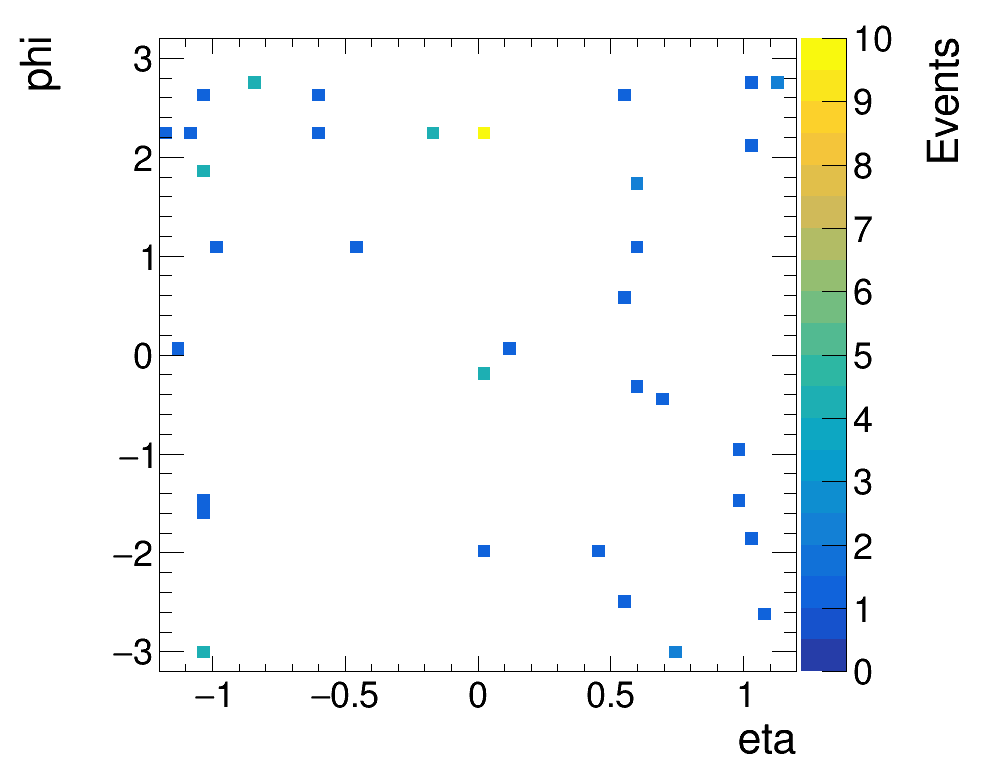

In [37]:

start_t = time.time()


c = rt.TCanvas('c','c', 1000, 800)
i = 3
cond = (station[i]==1)
h = create_TH2D(np.column_stack((np.array(eta[i][cond]), np.array(phi[i][cond]))) , axis_title = ['eta','phi','Events'], binning=[50,-1.2,1.2,50,-3.2,3.2])

h.Draw('colz')
c.SetRightMargin(0.2)

c.Draw()

